### Step 1: Import Libraries and Load APIs

In [1]:
import os
from dotenv import load_dotenv
from openai import OpenAI
import gradio as gr

load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
if OPENAI_API_KEY is None: 
    raise ValueError("Key not found")


/Users/gauravkamath/Documents/Code/ai-engineering/ai_env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Step2: 'Prerequisite' - Document to ingest into the RAG

In [2]:
document_culture_memo = """The Best Work of Our Lives
CULTURE MEMO
At Netflix, we aspire to entertain the world, thrilling audiences everywhere. To do that, we’ve
developed an unusual company culture focused on excellence, and creating an environment
where talented people can thrive — lifting ourselves, each other and our audiences higher and
higher. This document is about that culture, which is based on four core principles:
● The Dream Team: We aim only to have high performers at Netflix — people who are
great at what they do, and even better at working together.
● People over Process: You get better outcomes when employees have the information
and freedom to make decisions for themselves. We hire unusually responsible people
who thrive on this openness and freedom.
● Uncomfortably Exciting: To entertain the world, we need to be bold and ambitious.
That means embracing the thrill of what’s next — even when it’s uncomfortable.
● Great and Always Better: We often say Netflix sucks today compared to where we can
be tomorrow. We need the self-awareness to understand what should be better, and
the discipline and resilience to get there.
While we don’t always live up to these principles, most people who join Netflix are pleasantly
surprised by how great their colleagues are and the way we empower people at every level.
As our business grows and evolves, our culture (and this document) will, too. What won’t
change is our focus on excellence, and our determination to ensure that Netflix remains a
place where great people can do the best work of their lives. If this sounds exciting, you’ll
probably love it here. But Netflix is not for everyone, so please read on.
THE DREAM TEAM
We believe that what makes a fantastic workplace isn’t a great office or free meals and
massages — although we have some nice perks. It’s the people. Imagine working alongside
stunning colleagues who are great at what they do, and even better at working together. It’s
why we model ourselves on a professional sports team, not a family. Families are about
unconditional love. They can also be dysfunctional, as anyone who’s watched Ozark or
Wednesday knows. Professional sports teams, on the other hand, focus on performance and
picking the right person for every position, even when that means swapping out someone
they love for a better player.
© 2024 Netflix, Inc. All rights reserved. | Last updated: June 2024 | English Version
While every member of our Dream Team has different skills, we look for common strengths
that make us better together. These are the values we value:
● Selflessness — you are humble when searching for the best ideas; you seek what’s
best for Netflix, not yourself or your team; you take time to help others succeed.
● Judgment — you look beyond short term fixes in favor of long term solutions; you
make wise decisions despite ambiguity; you use data to inform your intuition.
● Candor — you willingly receive and give feedback; you are open about what’s working
and what needs to improve; you admit mistakes openly and share learnings widely.
● Creativity — you welcome new ideas; you are passionate and persistent in pursuit of
more innovative solutions; you value artistic expression.
● Courage — you are vulnerable in search for the truth; you are willing to risk failure, or
challenge the status quo, in the pursuit of excellence.
● Inclusion — you recognize your biases and work to counteract them; you try to ensure
everyone at Netflix can do their best work, whatever their culture, identity or
background.
● Curiosity — you learn rapidly and eagerly; you are more interested in other people’s
ideas than your own; you’re humble about what you don’t yet know.
● Resilience — you quickly adapt to changing circumstances; you make tough decisions
without agonizing or long delay; you embrace a hard challenge.
It’s easy to talk about values and harder to live by them. We all work hard to keep each other
accountable for upholding these standards, especially our leaders, because excellence and
honesty go hand in hand. It’s why we invest in strong professional relationships that build trust
and help people assume good intent. This, in turn, enables us to practice extraordinary
candor — ensuring constructive feedback is part of our everyday work (like brushing your
teeth). It takes courage and vulnerability to ask someone how you could do better, or to seek
alternative opinions about the best way forward, and integrity only to say things about a
colleague that you’re willing to share with them directly. This is especially true when you’re
giving feedback to someone more senior or from a different background, or if you come from
a culture or company where deference is the norm. But extraordinary candor helps us improve
faster as individuals and a company.
Since a high performer in any role is many times more effective than the average employee,
our Dream Team is driven by performance — not seniority, tenure or unconditional loyalty. It’s
also why we focus on maintaining a high performance culture. To recruit and retain stunning
colleagues, we pay personal top of market for the role and location — a judgment about what
that person could make in a similar role at another company, and what we would pay to keep
or replace them. We expect leaders to be strong developers of talent. And to ensure they have
the right player at every position, we ask them to apply what we call the “keeper test”
1 —
asking “if X wanted to leave, would I fight to keep them?” Or “knowing everything I know
today, would I hire X again?” If the answer is no, we believe it’s fairer to everyone to part ways
quickly.
1 The “keeper test” name came from our co-founder, Reed Hastings, who remembers catching a fish as a
child and his dad saying, “That’s a keeper, Reed!”
© 2024 Netflix, Inc. All rights reserved. | Last updated: June 2024 | English Version
In the abstract, the keeper test can sound scary. In reality, we encourage everyone to speak to
their managers about what’s going well and what’s not on a regular basis. This helps avoid
surprises. Managers also evaluate team members on their whole record, rather than focusing
on the mistakes or bets that didn’t pay off. On the Dream Team, you need people who
challenge the status quo and try new things. So we stick with employees through short-term
bumps.
No matter how brilliant someone may be, there’s no place in our Dream Team for people who
don’t treat their colleagues with decency and respect. When you have talented people who
work well together — trusting each other’s intentions and respecting their differences — it
makes everyone more successful.
PEOPLE OVER PROCESS
Many of us have worked at companies where decisions were made top down, there was little
transparency and it felt hard to make a difference — or even get basic things done. At Netflix,
we aim to inspire and empower more than just manage because people can have a greater
impact when they’re free to make decisions about their own work.
As part of this, we strive to develop good decision-making muscles at every level of the
company, priding ourselves on how few, not how many, decisions senior leaders make. We
expect managers to practice context not control — giving their teams the context and clarity
needed to make good decisions instead of trying to control everything themselves. We also
help employees learn by sharing a lot of information internally, including through memos
where they can comment and ask questions. It takes an unusually responsible person to
thrive on this level of freedom — someone who’s self-motivated, self-aware and
self-disciplined, who doesn’t wait to be told what to do and picks up the trash like they would
at home. That said, context not control should not be confused with hands-off management.
Managers need to be involved in the work being done around them, and actively coach their
teams. They may also have to step in when someone is about to make a decision that is
unethical or could materially harm Netflix, during a crisis or if a new team member lacks the
full context.
We avoid decision-making by committee, which tends to slow companies down and
undermine accountability. For every significant decision, we identify an informed captain
who’s responsible for making a judgment call on the right way ahead. Then different teams,
each led by their own informed captain, implement the decision. This highly aligned and
loosely coupled approach gives teams the freedom to move quickly and operate
independently, while ensuring responsibility for the outcome.
We’ve learned that the best ideas can come from anywhere, which is why we expect informed
captains to seek out different opinions and listen to people at every level. We call this farming
for dissent. Of course, not all opinions are created equal — and with 10,000-plus employees,
it’s impractical for everyone to weigh in on most decisions (this memo being an exception). So
on an important creative decision, for example, the opinion of someone working in TV, film or
games will carry more weight than an engineer, and vice versa when it comes to our product
or technology. After a decision is made, we expect everyone, including the people who argued
© 2024 Netflix, Inc. All rights reserved. | Last updated: June 2024 | English Version
for a different approach, to disagree and commit. This helps ensure the outcome is as
successful as possible. Afterwards, when the impact is clear, the informed captain should
reflect on their choices — what worked and what didn’t — so everyone can learn how to do
better next time.
Launching a game, TV show or film, running a marketing campaign, managing compensation
and closing a quarter all take process. And companies need strict rules against things like
harassment, marginalizing colleagues, leaking company information, or insider trading. But we
work hard to keep rules at Netflix to a minimum and ensure any process is good (simple,
efficient, impactful). Our vacation policy, for example, is two words: “Take vacation.” And our
expenses policy is just five words: “Act in Netflix’s best interests.” This (almost) no rules rule
gives employees the freedom to exercise their judgment. It also prevents the process creep
that typically happens when companies grow and try to dummy proof their organizations —
stifling creativity and making it harder for businesses to adapt.
You might think that this kind of freedom would lead to chaos. In reality, while we’ve had our
fair share of failures — and a few people have taken advantage of our culture in bad ways —
our emphasis on individual autonomy has created an extremely successful business, with
many opportunities for employees to develop and grow. In entertainment and technology, our
biggest threat is a lack of creativity, adaptability and innovation. It’s why trying to minimize
rules and processes (rather than errors) — while giving people the freedom to use their own
judgment and learn from their mistakes — is a far superior recipe for long-term success.
UNCOMFORTABLY EXCITING
Netflix is programming for well over half a billion
2 people globally — something no other
entertainment company has ever done before. Success requires us to be bold and ambitious,
to think differently, experiment and adapt (often quickly). This is true whether we’re designing
a new product feature, working to improve our recommendations, developing a marketing
campaign or creating a TV show or game. Many people will be happier at companies that are
more stable or take fewer risks. Netflix works best if you value experimentation, enjoy the
uncomfortable excitement of a new or challenging project and have the resilience to thrive in
this environment.
ARTISTIC EXPRESSION
Representation matters. Our members come from many different backgrounds and cultures,
and they want to see a wide variety of stories and people on screen. This diversity is
wonderful and it can create real tension since we all have such different views about what’s
acceptable — and what’s harmful — on TV. While every show, film or game is different, we
approach them with the same set of principles: we support the artistic expression of the
creators we choose to work with; we program for a wide variety of audiences, cultures and
tastes; and we provide ratings, content advisories and parental controls in multiple languages
to help members choose what to watch or play. As employees, we support these principles,
even if some stories run counter to our personal values. And we understand that, depending
2 As of Q1 2024 ~260 million households subscribe to Netflix. Assuming ~2 people per household —
which is conservative — that means our audience is over 500M.
© 2024 Netflix, Inc. All rights reserved. | Last updated: June 2024 | English Version
on our roles, we may need to work on TV shows, films or games we perceive to be harmful. If
you’d find it hard to support the breadth of our slate, Netflix is probably not the best place for
you.
GREAT AND ALWAYS BETTER
Netflix has come a long way since we mailed our first DVD in 1998. But we're nowhere close
to where we want to be in the future. It’s why we care so much about the Dream Team, putting
people over process and creating an environment where everyone feels a sense of
responsibility to make us better. We believe this approach is the surest path to excellence and
long term success.
It’s also why we constantly seek to improve our culture, not preserve it. Every new employee
helps shape how we work — finding new ways to accomplish more together. This creates a
better experience for our members, employees, creators and partners, which in turn propels
our long term growth and success. It’s how we entertain the world and build a wildly
successful business.
As he has since our first culture deck was written in 2009, Antoine de Saint-Exupéry, the
author of The Little Prince, shows us the way:
If you want to build a ship,
don't drum up the people
to gather wood, divide the
work, and give orders.
Instead, teach them to yearn
for the vast and endless sea.
© 2024 Netflix, Inc. All rights reserved. | Last updated: June 2024 | English Version

"""

In [3]:
document_work_life_philosophy = """For Netflix, a big part of our focus on excellence is hiring people who are great at what they do and creating an environment where talent can thrive. Being part of our Dream Team means you’ll have a choice of offerings to assist you in the moments that matter. Because when you feel covered in life, you can focus on doing your best work. Everyone’s needs are unique and we want to empower you to take care of yourself and make decisions that are right for your family. That starts with a flexible approach to the support Netflix provides at work and beyond.
Netflix Image 3060
Here to help you get there
Parental Leave
We recognize that one of the most special events in an individual's life is welcoming a new child. Our parental leave policy is: "take care of your child and yourself." We encourage employees to think about the time they’ll need as a parent and have a conversation with their manager and talent partners to determine what's best for them and Netflix.

TIME AWAY
Our vacation policy is “take vacation”, and we actually do. Frankly, we intermix work and personal time quite a bit. Time away works differently at Netflix. We don’t have a prescribed 9-to-5 workday, so we don’t have prescribed time off policies for salaried employees, either. We don’t set a holiday and vacation schedule, so you can observe what’s important to you—including when your mind and body need a break. While time away may be observed differently depending on your location and role, we believe in taking the time you need so you are bringing your best to work.

Family Forming & Reproductive Health
Netflix offers a global family forming benefit to support employees looking for preservation, fertility, surrogacy, and/or adoption options. These benefits are available to employees and their spouse/domestic partner, regardless of marital status, gender, or sexual orientation.

Mental Health Benefits
At Netflix, we know you want to produce work you are proud of. In order to perform your best, you have to feel your best. Mental health is important to your overall health which is why Netflix offers various programs to support you and your dependents. Globally, we provide access to mindfulness and meditation as well as free counseling and coaching sessions.

Health Benefits
Medical benefits work differently based on the country you live in. So you may have medical coverage offered through Netflix only, a supplemental plan through Netflix that compliments your local insurance scheme, or you may have a monthly allowance to purchase benefits on your own. No matter what the case is, we make sure that you’re covered.

FINANCES THAT MATTER TO YOU
Personal Top Of Market
To help us attract and retain stunning colleagues, we pay employees at the top of their personal market. We do not think of these as “raises” and there is no raise pool to divide up. The market for talent is what it is and is not defined by set bands and grades. If your market adjusts, we do not have to wait for an annual compensation event to make changes. We hope through this compensation approach, we can dismantle pay disparities across gender and race.

Stock Option Program
Employees choose each year how much of their eligible compensation they want in salary versus stock options which provides the opportunity to benefit from Netflix’s long term success as our stock price appreciates. You can choose all cash, all options, or whatever combination suits you. These 10-year stock options are fully-vested and you keep them even if you leave Netflix.

Employee Giving Program
At Netflix, you have the ability to impact the world through your work, sharing great storytelling globally. We realize you may also want to make an impact in a more personal way by giving to or volunteering with charitable organizations you care about. We want to do our part to support you and the organizations important to you by matching your monetary donations and volunteer time through our Employee Giving Program.

Netflix Image 5004
03 NOV 17-NOV (©Tiffany Luong 2024)-00671 copy f p (1)
Convenience to Do Your Best Work
Expenses and Work-Related Travel
Our policy for travel, entertainment, gifts, and other expenses is 5 words long: “act in Netflix’s best interest.” We do not have a set travel policy at Netflix. Using our guiding principles of context, not control - you can use judgment to make decisions that are effective for the business and set you up for success. If in doubt, seek to understand.

Work, Not Drive
This program gives you flexibility to take a call, respond to your emails, and focus on work from a rideshare car on your way to and from the office.

Relocation Benefits
We are not bound by policies and restrictions of where great talent is located. When relocating at the request of Netflix to one of our offices, from one city, or country, to another, we have a team dedicated to supporting you and your family. We understand that relocating can be multi-faceted and that there is a lot to consider. Our goal is to remove distractions by providing inclusive, fair, and meaningful support, which allows our stunning colleagues to settle quickly and focus on their role at Netflix."""



In [4]:
document_2025_annual_report_intro = """PART I
Forward-Looking Statements
This Annual Report on Form 10-K contains forward-looking statements within the meaning of the federal securities laws. These forward-looking
statements include, but are not limited to, statements regarding: our core strategy; our ability to improve our content of erings and service; our future financial
performance, including expectations regarding revenues, deferred revenue, operating income and margin, net income, expenses, and profitability; liquidity,
including the suf iciency of our capital resources, cash requirements; net cash provided by (used in) operating activities, access to financing sources, and free
cash flows; capital allocation strategies, including any stock repurchases or repurchase programs; stock price volatility; impact of foreign exchange rate
fluctuations; expectations regarding hedging activity; impact of interest rate fluctuations; adequacy of existing facilities; future regulatory changes and their
impact on our business; intellectual property; cybersecurity; price changes and testing; artificial intelligence (“AI”); accounting treatment for changes related
to content assets; acquisitions; actions by competitors; membership growth, including impact of content and pricing changes on membership growth;
partnerships; advertising; multi-household usage; member viewing patterns; dividends; future contractual obligations, including unknown content obligations
and timing of payments; our global content and marketing investments, including investments in original programming, consumer products and live
experiences; impact of work stoppages; content amortization; resolutions of tax examinations; tax expense; unrecognized tax benefits; deferred tax assets; tax
deposits; resolutions of disputes and other proceedings; our ability to ef ectively manage change and growth; our company culture; expectations regarding the
transaction with Warner Bros. Discovery, Inc. ("WBD"); and our ability to attract and retain qualified employees and key personnel. These forward-looking
statements are subject to risks and uncertainties that could cause actual results and events to dif er. A detailed discussion of these and other risks and
uncertainties that could cause actual results and events to dif er materially from such forward-looking statements is included throughout this filing and
particularly in Item 1A: “Risk Factors” section set forth in this Annual Report on Form 10-K. All forward-looking statements included in this document are
based on information available to us on the date hereof, and we assume no obligation to revise or publicly release any revision to any such forward-looking
statement, except as may otherwise be required by law.
Item 1. Business
ABOUT US
Netflix, Inc. (“Netflix”, the “Company”, “registrant”, “we”, or “us”) is one of the world’s leading entertainment services offering TV series, films, games
and live programming across a wide variety of genres and languages. Members can play, pause and resume watching as much as they want, anytime, anywhere,
and can change their plans at any time.
Our core strategy is to grow our business globally within the parameters of our operating margin target. We strive to continuously improve our members'
experience by offering compelling content that delights them and attracts new members. We aim to offer a range of pricing plans, including our ad-supported
subscription plan, to meet a variety of consumer needs. We seek to drive conversation around our content to further enhance member joy, and we are
continuously enhancing our user interface to help our members more easily choose content that they will find enjoyable.
BUSINESS SEGMENTS
We operate as one operating segment. Our revenues are primarily derived from monthly membership fees for services related to streaming content to our
members. See Note 13, Segment and Geographic Information, in the accompanying notes to our consolidated financial statements for further detail.
COMPETITION
The market for entertainment video is intensely competitive and subject to rapid change. We compete with a broad set of activities for consumers’ leisure
time, including other entertainment video providers, such as linear television, streaming entertainment providers (including those that provide pirated content),
video gaming providers, open content platform providers, which provide access to user-generated and professionally produced content, as well as more broadly
against other sources of entertainment, such as social media, that our members could choose in their moments of free time. We also compete against
entertainment video providers and content producers in obtaining content for our service, both for licensed content and for original content projects.
While consumers may maintain simultaneous relationships with multiple entertainment sources, we strive for consumers to choose us in their moments of
free time. We have often referred to this choice as our objective of “winning moments of truth.” In attempting to win these moments of truth with our members,
we seek to continually improve our service, including both our technology and our content offerings.
1
Table of Contents
INTELLECTUAL PROPERTY
We regard our trademarks, service marks, copyrights, patents, domain names, trade dress, trade secrets, proprietary technologies and similar intellectual
property as important to our success. We use a combination of patent, trademark, copyright and trade secret laws and confidentiality agreements to protect our
proprietary intellectual property. Our intellectual property rights extend to our technology, business processes, the content we produce and distribute through
our service, and the consumer products and experiences based thereon. We use the intellectual property of third parties in creating some of our content,
merchandising our products and marketing our service. Our ability to provide our members with content they can watch depends on studios, content providers
and other rights holders licensing rights, including distribution rights, to such content and certain related elements thereof, such as the public performance of
music contained within the content we distribute. The license periods and the terms and conditions of such licenses vary. Our ability to protect and enforce our
intellectual property rights is subject to certain risks and from time to time we encounter disputes over rights and obligations concerning intellectual property.
We cannot provide assurance that we will prevail in any intellectual property disputes.
REGULATION
The media landscape and the internet delivery of content have seen growing regulatory action. Historically, media has been highly regulated in many
countries. We are seeing some of these legacy regulatory frameworks be updated and expanded to address services like ours. In particular, we are seeing some
countries update their cultural support legislation to include services like Netflix. This includes investment obligations, levies, and content catalog quotas.
Some even restrict the extent of ownership rights we can have both in our service and in our content. In certain countries, regulators are also looking at
restrictions that could require formal reviews of and/or adjustments to content that appears on our service in their country. In general these regulations impact
all services and may make operating in certain jurisdictions more expensive or restrictive as to the content offerings we may provide.
HUMAN CAPITAL
Our business is to entertain the world across different countries, cultures, languages and tastes. To entertain an audience this global, our Company needs
to reflect the world and the variety of stories we tell. To help ensure our workforce is representative of the members we serve, we employ people in multiple
countries around the world and work to maintain a global culture of inclusion. We view our employees and our culture as key to our success. As of
December 31, 2025, we had approximately 16,000 full-time employees. Of these, approximately 10,900 (68%) were located in the United States and Canada,
2,500 (16%) in Europe, Middle East, and Africa, 1,900 (12%) in Asia-Pacific and 700 (4%) in Latin America. We also have a number of employees engaged in
content production, some of whom are part-time or temporary, and whose numbers fluctuate throughout the year and may be covered by collective bargaining
agreements.
We believe an important component of our success is our company culture as detailed in the “Netflix Culture Memo”, which was updated in 2024. Our
culture is focused on excellence and creating an environment where talented people can thrive — lifting ourselves, each other and our audiences higher and
higher. We engage employees and seek feedback through regular town halls, surveys, business reviews and memos, which we often share broadly, inviting
comments. We aim to attract and retain great people — representing a broad array of perspectives and skills — to work together as a dream team. For more
people and cultures to see themselves reflected on screen, it is important that our employee base represents the communities we serve.
We aim generally to pay our employees at their personal top of market, and they generally are able to choose the form of their compensation between
cash and stock options. This permits employee compensation to be highly personalized and reflective of each employee's individual needs and preferences. We
conduct pay equity analyses at least annually, and have adopted practices to help ensure that employees from underrepresented groups are not being underpaid
based on gender identity (globally) and race or ethnicity (United States (“U.S.”)) relative to others doing the same or similar work under comparable
circumstances. We aim to rectify any pay gaps that we find through this analysis.
We care about the health and well-being of our employees and their families and provide a variety of benefit programs based on region, including health
benefits. In the U.S., employees generally receive an annual cash health benefit allowance that they may allocate to medical, dental and vision premiums in a
way that makes sense for them. Employees have access to a host of other benefits, including mental health, childcare, family planning and a company match
for charitable donations.
We believe that our approach to human capital resources has been instrumental in our growth, and has made Netflix a desirable destination for employees.
OTHER INFORMATION
We maintain a website at www.netflix.com. The contents of our website are not incorporated in, or otherwise to be regarded as part of, this Annual Report
on Form 10-K. We make available, free of charge on our website, access to our Annual Report on Form 10-K, our Quarterly Reports on Form 10-Q, our
Current Reports on Form 8-K and amendments to those reports filed or furnished pursuant to Section 13(a) or 15(d) of the Securities Exchange Act of 1934, as
amended (the “Exchange Act”), as soon as reasonably practicable after we file or furnish them electronically with the Securities and Exchange Commission
(“SEC”).
2
Table of Contents
Investors and others should note that we announce material financial and other information to our investors using our investor relations website
(ir.netflix.net), SEC filings, press releases, public conference calls and webcasts. We use these channels as well as social media and blogs to communicate with
our members and the public about our company, our services and other issues. It is possible that the information we post on social media and blogs could be
deemed to be material information. Therefore, we encourage investors, the media, and others interested in our company to review the information we post on
the social media channels and blogs listed on our investor relations website"""

### Step 3: Chunking - Vibe coded
##### Prompt: write a python function splits a long text into overlapping chunks of up to 500 characters (input variable), where each chunk overlaps the previous one by 50 characters(input variable) and if a chunk ends in the middle of a sentence or paragraph, it should try to move the cut back to the natural boundary like a paragraph break, new line, sentence end, or space( in that order), but only if that boundary is past halfway point of the chunk; the function should return the list of chunks

In [5]:
# Chunking function. 
import re

def chunk_text(text, chunk_size=500, overlap=50):
    """
    Split text into overlapping chunks, snapping cuts to natural boundaries
    (paragraph break > newline > sentence end > space) when possible.
    """
    chunks = []
    start = 0
    text_length = len(text)
    halfway = chunk_size // 2
    sentence_end_re = re.compile(r'[.!?](?=\s|$)')

    while start < text_length:
        end = start + chunk_size

        if end >= text_length:
            chunks.append(text[start:text_length])
            break

        window = text[start:end]
        min_cut = start + halfway
        cut = None

        for pattern, is_regex in [
            (r'\n\s*\n', True),   # paragraph break
            ('\n', False),        # newline
            (sentence_end_re, True),  # sentence end
            (' ', False),         # space
        ]:
            if is_regex:
                regex = pattern if isinstance(pattern, re.Pattern) else re.compile(pattern)
                matches = list(regex.finditer(window))
                if matches:
                    candidate = start + matches[-1].end()
                    if candidate >= min_cut:
                        cut = candidate
                        break
            else:
                idx = window.rfind(pattern)
                if idx != -1:
                    candidate = start + idx + len(pattern)
                    if candidate >= min_cut:
                        cut = candidate
                        break

        if cut is None:
            cut = end

        chunks.append(text[start:cut])
        start = cut - overlap

    return chunks

In [6]:
import uuid
documents = [
    {"text": document_culture_memo, "source":"Netflix Culture Demo"},
    {"text": document_work_life_philosophy, "source": "Netflix Work-Life Philosophy"},
    {"text": document_2025_annual_report_intro, "source": "Netflix 2025 Annual Reprot Introduction"}
]

chunks = []
ids = []
metadatas = []

for doc in documents:
    # Prepare the lists
    chunks_ = chunk_text(doc["text"], 500, 50)
    #ids_ = [f"{doc["source"]}_chunk_{i}"for i in range(len(chunks_))]
    ids_ = [str(uuid.uuid4()) for _ in range(len(chunks_))]
    metadatas_ = [{"source": doc["source"], "chunk_index":i} for i in range(len(chunks_))]

    # Add the main lists
    chunks.extend(chunks_)
    ids.extend(ids_)
    metadatas.extend(metadatas_)


print(f"Created {len(chunks)} chunks \n")

for i, chunk in enumerate(chunks):
    #print(f" --- Chunk {i+1} | {len(chunk)} chars --- ")
    print(f"Chunk {i} (ID: {ids[i]}, Source: {metadatas[i]['source']}, Index: {metadatas[i]['chunk_index']})")
    print(chunk)
    print()

Created 85 chunks 

Chunk 0 (ID: da8f95bf-715c-4cbf-85a6-31791576e9ce, Source: Netflix Culture Demo, Index: 0)
The Best Work of Our Lives
CULTURE MEMO
At Netflix, we aspire to entertain the world, thrilling audiences everywhere. To do that, we’ve
developed an unusual company culture focused on excellence, and creating an environment
where talented people can thrive — lifting ourselves, each other and our audiences higher and
higher. This document is about that culture, which is based on four core principles:
● The Dream Team: We aim only to have high performers at Netflix — people who are


Chunk 1 (ID: ce2f154f-2a87-4724-a343-f41760ff279c, Source: Netflix Culture Demo, Index: 1)
 have high performers at Netflix — people who are
great at what they do, and even better at working together.
● People over Process: You get better outcomes when employees have the information
and freedom to make decisions for themselves. We hire unusually responsible people
who thrive on this openness and fre

### Step 4: Generate Embeddings for all Chunks

In [7]:
# Generate Embeddings for all Chunks

client = OpenAI()
from pprint import pprint

response = client.embeddings.create(
    model = "text-embedding-3-small",
    input = chunks
)
pprint(response.data)


embeddings = [item.embedding for item in response.data]


[Embedding(embedding=[0.03277587890625, 0.0212249755859375, -0.044158935546875, 0.035858154296875, 0.034393310546875, -0.055450439453125, -0.032958984375, 0.059967041015625, -0.0330810546875, 0.007160186767578125, 0.03485107421875, -0.016571044921875, -0.037200927734375, -0.0489501953125, 0.0232696533203125, 0.03106689453125, -0.016876220703125, -0.043792724609375, 0.0026645660400390625, -0.050933837890625, 0.017059326171875, 0.035247802734375, -0.006381988525390625, 0.02349853515625, 0.0131378173828125, 0.012054443359375, -0.0758056640625, 0.07281494140625, -0.028778076171875, -0.0242462158203125, -0.0285186767578125, -0.0157928466796875, 0.024505615234375, -0.0103607177734375, 0.03717041015625, 0.0231781005859375, 0.02264404296875, 0.003662109375, 0.03851318359375, -0.0035839080810546875, 0.0001958608627319336, -0.0161895751953125, 0.0650634765625, 0.03656005859375, 0.01467132568359375, -0.0244903564453125, 0.0050811767578125, 0.02093505859375, 0.0189971923828125, 0.05792236328125, -

In [8]:
# Verify embeddings
print(f"Generated {len(embeddings)} embeddings")
print(f"Each embedding has {len(embeddings[0])} dimensions")

Generated 85 embeddings
Each embedding has 1536 dimensions


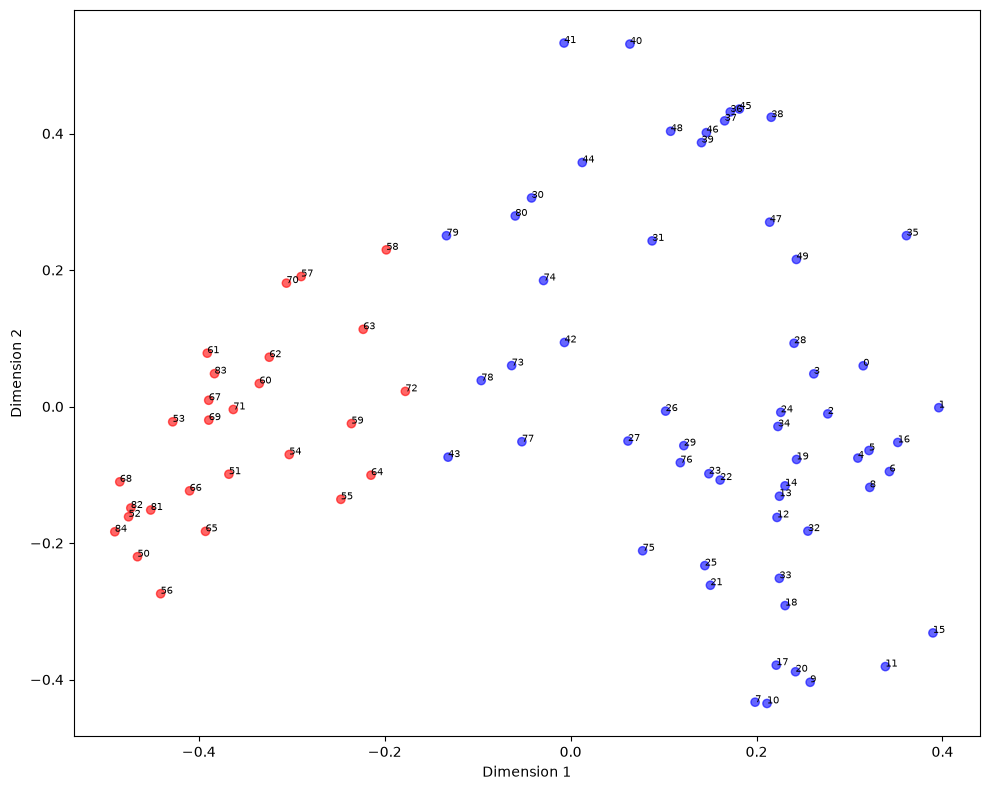

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 2. cluster in original high-dim space (more accurate than clustering after reduction)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(embeddings)

# 3. reduce to 2D for plotting
xy = PCA(n_components=2).fit_transform(embeddings)

# 4. plot, colored by cluster
colors = np.array(['red', 'blue'])
plt.figure(figsize=(10, 8))
plt.scatter(xy[:, 0], xy[:, 1], c=colors[cluster_labels], alpha=0.6)
for i, (x, y) in enumerate(xy):
    plt.annotate(str(i), (x, y), fontsize=7)
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.tight_layout()
plt.show()

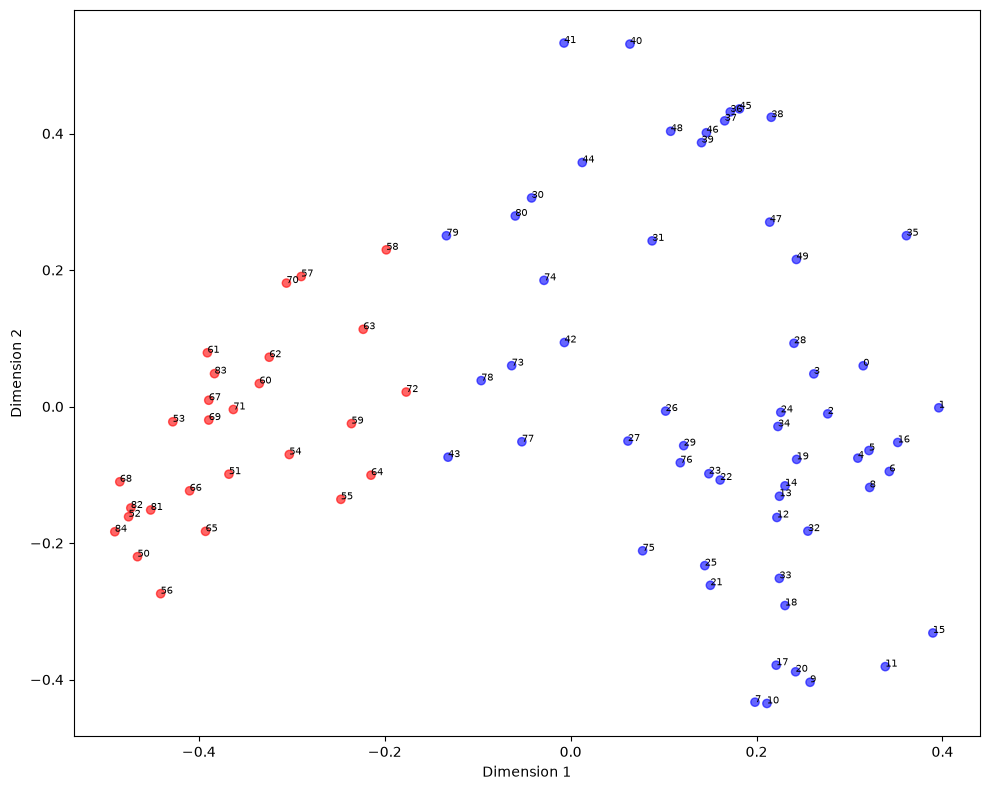

RED cluster (n=27): The common theme across these text chunks is the discussion of Netflix's forward-looking statements regarding its business strategies, financial expectations, and operational plans, including a focus on content offerings, market growth, and member experiences, while also acknowledging the risks and uncertainties that may affect future performance.

BLUE cluster (n=58): The common theme in these text chunks is Netflix's emphasis on a high-performing corporate culture grounded in excellence, accountability, and collaboration. The company seeks to cultivate a team of ambitious and talented individuals who prioritize personal growth, open communication, and resilience, fostering an environment where employees can do their best work.



In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1. get embeddings
response = client.embeddings.create(
    model="text-embedding-3-small",
    input=chunks
)
embeddings = np.array([item.embedding for item in response.data])

# 2. cluster in original high-dim space
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(embeddings)

# 3. reduce to 2D for plotting
xy = PCA(n_components=2).fit_transform(embeddings)

# 4. plot, colored by cluster
colors = np.array(['red', 'blue'])
plt.figure(figsize=(10, 8))
plt.scatter(xy[:, 0], xy[:, 1], c=colors[cluster_labels], alpha=0.6)
for i, (x, y) in enumerate(xy):
    plt.annotate(str(i), (x, y), fontsize=7)
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.tight_layout()
plt.show()

# 5. describe each cluster using an LLM
for cluster_id in [0, 1]:
    cluster_chunks = [c for c, l in zip(chunks, cluster_labels) if l == cluster_id]
    sample_text = "\n---\n".join(cluster_chunks[:10])  # cap sample size to stay within context

    resp = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{
            "role": "user",
            "content": f"These text chunks belong to the same cluster. In 1-2 sentences, describe the common theme:\n\n{sample_text}"
        }]
    )
    color = "RED" if cluster_id == 0 else "BLUE"
    print(f"{color} cluster (n={len(cluster_chunks)}): {resp.choices[0].message.content}\n")

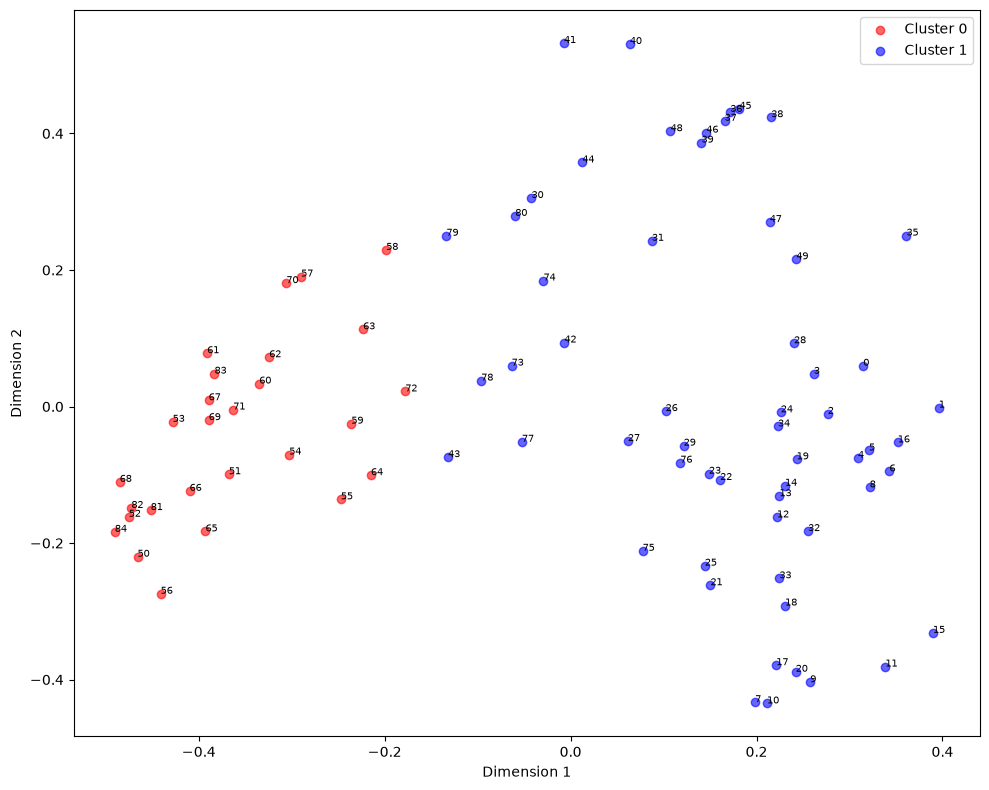

RED cluster (n=27): The common theme across these text chunks is Netflix's forward-looking strategy and operational focus, which includes ambitions for financial performance, content offerings, member experience enhancement, and adaptability to market changes and regulatory environments. It also highlights the risks and uncertainties associated with these projections, underscoring the company's commitment to growth and innovation in the entertainment sector.

BLUE cluster (n=58): The common theme in these text chunks revolves around Netflix's unique corporate culture, which emphasizes excellence, high performance, and collaboration among talented individuals. It highlights the importance of values such as selflessness, candor, and resilience, ensuring a work environment where employees are empowered to make decisions and embrace bold challenges to achieve their best work.



In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1. get embeddings
response = client.embeddings.create(
    model="text-embedding-3-small",
    input=chunks
)
embeddings = np.array([item.embedding for item in response.data])

# 2. cluster in original high-dim space
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(embeddings)

# 3. reduce to 2D for plotting
xy = PCA(n_components=2).fit_transform(embeddings)

# 4. plot, colored by cluster, with legend
colors = np.array(['red', 'blue'])
plt.figure(figsize=(10, 8))
for cluster_id, color, name in [(0, 'red', 'Cluster 0'), (1, 'blue', 'Cluster 1')]:
    mask = cluster_labels == cluster_id
    plt.scatter(xy[mask, 0], xy[mask, 1], c=color, alpha=0.6, label=name)

for i, (x, y) in enumerate(xy):
    plt.annotate(str(i), (x, y), fontsize=7)

plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()
plt.tight_layout()
plt.show()

# 5. describe each cluster using an LLM
for cluster_id in [0, 1]:
    cluster_chunks = [c for c, l in zip(chunks, cluster_labels) if l == cluster_id]
    sample_text = "\n---\n".join(cluster_chunks[:10])

    resp = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{
            "role": "user",
            "content": f"These text chunks belong to the same cluster. In 1-2 sentences, describe the common theme:\n\n{sample_text}"
        }]
    )
    color = "RED" if cluster_id == 0 else "BLUE"
    print(f"{color} cluster (n={len(cluster_chunks)}): {resp.choices[0].message.content}\n")

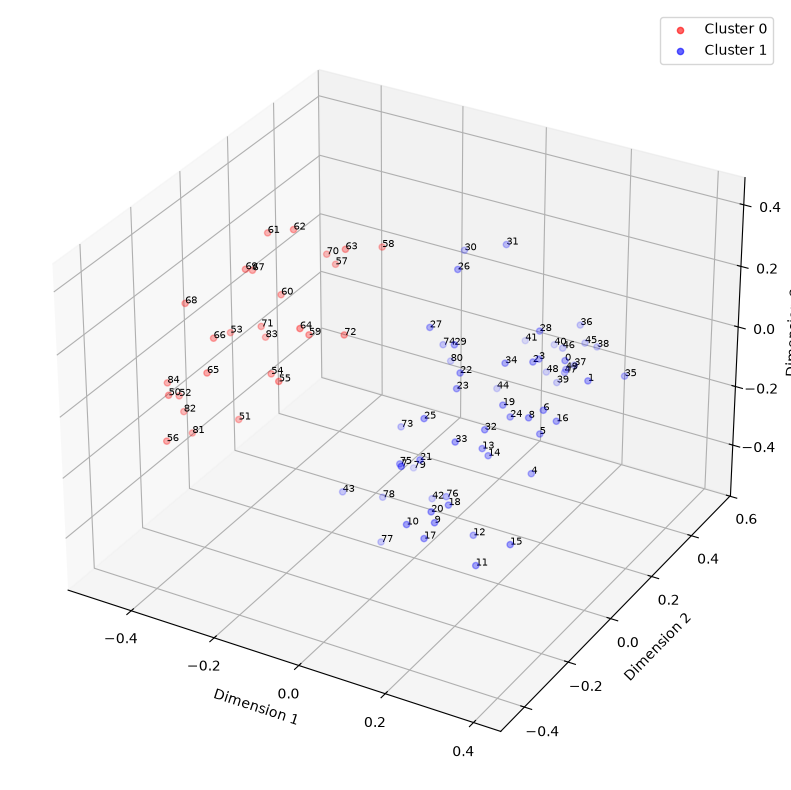

RED cluster (n=27): The common theme in these text chunks is Netflix's strategic planning and outlook, focusing on its forward-looking statements regarding future financial performance, business operations, content offerings, and overall growth strategy to enhance member experience and attract new subscribers amidst various market uncertainties and risks.

BLUE cluster (n=58): The common theme in these text chunks revolves around Netflix's unique company culture, which emphasizes excellence, high performance, and a collaborative environment where employees are empowered to make decisions and embrace challenges. The principles outlined highlight the importance of teamwork, personal responsibility, and continuous improvement, creating a workplace that values both individual and collective success.



In [13]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (enables 3D projection)
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1. get embeddings
response = client.embeddings.create(
    model="text-embedding-3-small",
    input=chunks
)
embeddings = np.array([item.embedding for item in response.data])

# 2. cluster in original high-dim space
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(embeddings)

# 3. reduce to 3D for plotting
xyz = PCA(n_components=3).fit_transform(embeddings)

# 4. plot, colored by cluster, with legend
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for cluster_id, color, name in [(0, 'red', 'Cluster 0'), (1, 'blue', 'Cluster 1')]:
    mask = cluster_labels == cluster_id
    ax.scatter(xyz[mask, 0], xyz[mask, 1], xyz[mask, 2], c=color, alpha=0.6, label=name)

for i, (x, y, z) in enumerate(xyz):
    ax.text(x, y, z, str(i), fontsize=7)

ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")
ax.set_zlabel("Dimension 3")
ax.legend()
plt.tight_layout()
plt.show()

# 5. describe each cluster using an LLM
for cluster_id in [0, 1]:
    cluster_chunks = [c for c, l in zip(chunks, cluster_labels) if l == cluster_id]
    sample_text = "\n---\n".join(cluster_chunks[:10])

    resp = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{
            "role": "user",
            "content": f"These text chunks belong to the same cluster. In 1-2 sentences, describe the common theme:\n\n{sample_text}"
        }]
    )
    color = "RED" if cluster_id == 0 else "BLUE"
    print(f"{color} cluster (n={len(cluster_chunks)}): {resp.choices[0].message.content}\n")

In [14]:
import numpy as np
import plotly.express as px
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import nbformat

# 1. get embeddings
response = client.embeddings.create(
    model="text-embedding-3-small",
    input=chunks
)
embeddings = np.array([item.embedding for item in response.data])

# 2. cluster in original high-dim space
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(embeddings)

# 3. reduce to 3D for plotting
xyz = PCA(n_components=3).fit_transform(embeddings)

# 4. plot, colored by cluster, rotatable
labels = [f"#{i}: {c[:50]}" for i, c in enumerate(chunks)]
fig = px.scatter_3d(
    x=xyz[:, 0], y=xyz[:, 1], z=xyz[:, 2],
    color=cluster_labels.astype(str),
    color_discrete_map={'0': 'red', '1': 'blue'},
    hover_name=labels,
    labels={'x': 'Dimension 1', 'y': 'Dimension 2', 'z': 'Dimension 3', 'color': 'Cluster'}
)
fig.update_traces(marker=dict(size=5))
fig.show()

# 5. describe each cluster using an LLM
for cluster_id in [0, 1]:
    cluster_chunks = [c for c, l in zip(chunks, cluster_labels) if l == cluster_id]
    sample_text = "\n---\n".join(cluster_chunks[:10])

    resp = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{
            "role": "user",
            "content": f"These text chunks belong to the same cluster. In 1-2 sentences, describe the common theme:\n\n{sample_text}"
        }]
    )
    color = "RED" if cluster_id == 0 else "BLUE"
    print(f"{color} cluster (n={len(cluster_chunks)}): {resp.choices[0].message.content}\n")

RED cluster (n=27): The common theme in these text chunks revolves around Netflix's strategic business planning and operational outlook, particularly its focus on forward-looking statements related to financial performance, growth strategies, content offerings, and competitive positioning in the entertainment industry. The statements reflect an emphasis on improving user experience, capital allocation, and managing risks while navigating the dynamic landscape of media consumption.

BLUE cluster (n=58): The common theme across these text chunks is Netflix's unique company culture, which emphasizes excellence, high performance, and collaboration among talented individuals. It highlights principles such as prioritizing people over processes, encouraging boldness and innovation, and fostering an environment of accountability and continuous improvement to empower employees to do their best work.



### Step 5: Chroma DB - DB Intitalize, get or create Collection.

In [15]:
import chromadb

# Intialize the Chroma DB
chroma_client = chromadb.PersistentClient(path= "./chroma_db")

#intialize ChromaDB Client (In Memory Storage)
# chroma_client = chromadb.client()

collection = chroma_client.get_or_create_collection(name="netflix_document")

# Empty the collection before adding the new data.
if collection.get()["ids"]:
    collection.delete(collection.get()["ids"]) 

print(collection.get())

{'ids': [], 'embeddings': None, 'documents': [], 'uris': None, 'included': ['metadatas', 'documents'], 'data': None, 'metadatas': []}


### Step 6: Chroma DB - Prepare the data for storage

In [16]:
#prepare the data for storage

# ids = [f"chunk_{i}" for i in range(len(chunks))]
# metadatas = [{"source": "netflix_culture_pdf", "chunk_index":i} for i in range(len(chunks))]
#print(embeddings)
collection.add(
    ids=ids,
    embeddings=embeddings,
    documents=chunks,
    metadatas=metadatas
)

pprint(collection.get(include=["metadatas", "documents", "embeddings"]))

{'data': None,
 'documents': ['The Best Work of Our Lives\n'
               'CULTURE MEMO\n'
               'At Netflix, we aspire to entertain the world, thrilling '
               'audiences everywhere. To do that, we’ve\n'
               'developed an unusual company culture focused on excellence, '
               'and creating an environment\n'
               'where talented people can thrive — lifting ourselves, each '
               'other and our audiences higher and\n'
               'higher. This document is about that culture, which is based on '
               'four core principles:\n'
               '● The Dream Team: We aim only to have high performers at '
               'Netflix — people who are\n',
               ' have high performers at Netflix — people who are\n'
               'great at what they do, and even better at working together.\n'
               '● People over Process: You get better outcomes when employees '
               'have the information\n'
        

### Step 7: User Query
#### Embed the Query --> Search in Chroma Vector DB

In [19]:
#Generate embedding for a test query
test_query = "days off"

# 1. get embeddings
response = client.embeddings.create(
    model="text-embedding-3-small",
    input=test_query
)

#print(response.data)
embeddings = np.array([item.embedding for item in response.data])

#print(embeddings[0])

#collection.query()

results = collection.query(
    query_embeddings=embeddings,
    n_results=3,
    include=["documents", "metadatas", "embeddings"]
)

#print(results["metadatas"] )

print(f"Search Query: {test_query}\n")
print("Retrieved Chunks \n")
for a, b in zip(results["documents"][0], results["metadatas"][0]):
    print(f"Document {b["source"]} Chunk{b['chunk_index']}: \n{a}\n ")


Search Query: days off

Retrieved Chunks 

Document Netflix Work-Life Philosophy Chunk3: 
s to determine what's best for them and Netflix.

TIME AWAY
Our vacation policy is “take vacation”, and we actually do. Frankly, we intermix work and personal time quite a bit. Time away works differently at Netflix. We don’t have a prescribed 9-to-5 workday, so we don’t have prescribed time off policies for salaried employees, either. We don’t set a holiday and vacation schedule, so you can observe what’s important to you—including when your mind and body need a break.
 
Document Netflix Work-Life Philosophy Chunk4: 
ou—including when your mind and body need a break. While time away may be observed differently depending on your location and role, we believe in taking the time you need so you are bringing your best to work.

Family Forming & Reproductive Health
Netflix offers a global family forming benefit to support employees looking for preservation, fertility, surrogacy, and/or adoption option

### Step 7.1: System Prompt for the LLM. 

In [22]:
system_message = "You are an helpful assistent that answers questions based on the provided context.\
    If you dont know the answer, say you dont know. Alwys use all available information to provide\
        best answer possible."

### Step 7.2: 
#### a. Stitch retrieved Chunks together to create the context for the response.
#### b. Embed the context --> Search in Chroma Vector DB

In [23]:
def respond_to_ai(message, history):
    client = OpenAI(api_key=OPENAI_API_KEY)
    # RAG
    # 1. get embeddings
    response = client.embeddings.create(
        model="text-embedding-3-small",
        input=[message]
    )

    #embeddings = np.array([item.embedding for item in response.data])
    embeddings = response.data[0].embedding

    results = collection.query(
        query_embeddings=embeddings,
        #n_results=3,
        #include=["documents", "metadatas", "embeddings"]
    )

    #stitch retrieved Chunks together to create the context for the response
    context = "\n---\n".join(results["documents"][0])
    print("Retrieved Chunks \n")
    for a, b in zip(results["documents"][0], results["metadatas"][0]):
        print(f"Document {b["source"]} Chunk{b['chunk_index']}: \n{a}\n ")

    system_message_enhanced = system_message + "\n\n Context:\n" + context
    # As usual
    messages = [{"role": "system", "content": system_message_enhanced}] + history + [{"role": "user", "content": message}]  
    #print("Messages sent to the model: \n" + system_message_enhanced  )  # Debugging line to see the messages being sent to the model
    
    response = client.chat.completions.create(
        model= "gpt-4.1-mini",
        messages=messages
    )

    reply = response.choices[0].message.content
    return reply

### Gradio for RAG communication.

In [ ]:
gr.ChatInterface(fn=respond_to_ai).launch(inbrowser=True)

/Users/gauravkamath/Documents/Code/ai-engineering/ai_env/lib/python3.14/site-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)


Retrieved Chunks 

Document Netflix 2025 Annual Reprot Introduction Chunk25: 
lix Culture Memo”, which was updated in 2024. Our
culture is focused on excellence and creating an environment where talented people can thrive — lifting ourselves, each other and our audiences higher and
higher. We engage employees and seek feedback through regular town halls, surveys, business reviews and memos, which we often share broadly, inviting

 
Document Netflix Culture Demo Chunk33: 
 our culture, not preserve it. Every new employee
helps shape how we work — finding new ways to accomplish more together. This creates a
better experience for our members, employees, creators and partners, which in turn propels
our long term growth and success. It’s how we entertain the world and build a wildly
successful business.
As he has since our first culture deck was written in 2009, Antoine de Saint-Exupéry, the
author of The Little Prince, shows us the way:
If you want to build a ship,

 
Document Netflix Cult

/Users/gauravkamath/Documents/Code/ai-engineering/ai_env/lib/python3.14/site-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
